# Exploratory Data Analysis — Customer Churn

Goal: understand what separates churned from active customers before modeling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("../data/processed/customer_features.parquet")
df.head()

,Customer ID,recency_days,frequency,monetary_total,distinct_products,country,avg_order_value,tenure_days,num_returns,return_rate,churned
0,12346.0,235,12,77556.46,27,United Kingdom,6463.038333,400,13.0,1.083333,1
1,12347.0,39,6,3402.39,107,Iceland,567.065000,274,0.0,0.000000,0
2,12348.0,158,4,1388.40,24,Finland,347.100000,189,0.0,0.000000,0
3,12349.0,317,2,2221.14,89,Italy,1110.570000,181,5.0,2.500000,0
4,12350.0,219,1,294.40,16,Norway,294.400000,0,0.0,0.000000,1


## 1. Churn balance

In [2]:
df["churned"].value_counts(normalize=True)

churned
1    0.56439
0    0.43561
Name: proportion, dtype: float64

## 2. Feature means: churned vs active

In [3]:
num_cols = ["recency_days","frequency","monetary_total","avg_order_value",
            "distinct_products","tenure_days","num_returns","return_rate"]
df.groupby("churned")[num_cols].mean()

,recency_days,frequency,monetary_total,avg_order_value,distinct_products,tenure_days,num_returns,return_rate
churned,,,,,,,,
0,120.048908,9.176856,4540.651864,396.127543,111.875109,319.973799,4.874236,0.515661
1,272.848332,3.049208,1113.586110,342.919564,45.747893,150.829794,1.318841,0.406619


**Observation:** churned customers have much higher recency (272 vs 120 days), roughly a third the order frequency (3.0 vs 9.2), and half the distinct products bought (46 vs 112) compared to active customers.

## 3. Correlation with churn

In [4]:
corr = df[num_cols + ["churned"]].corr()["churned"].sort_values()
corr

tenure_days         -0.383686
distinct_products   -0.312323
frequency           -0.270094
num_returns         -0.177526
monetary_total      -0.140222
avg_order_value     -0.048921
return_rate         -0.033774
recency_days         0.434874
churned              1.000000
Name: churned, dtype: float64

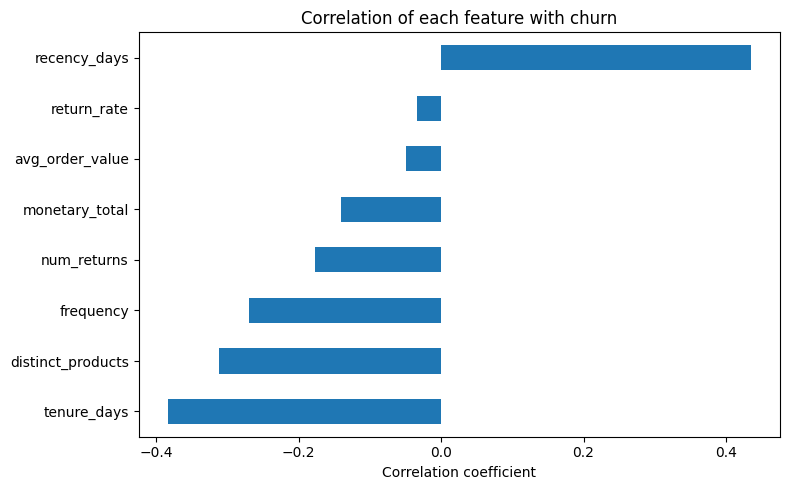

In [5]:
plt.figure(figsize=(8,5))
corr.drop("churned").plot(kind="barh")
plt.title("Correlation of each feature with churn")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

**Observation:** `tenure_days` (-0.38), `recency_days` (+0.43) and `distinct_products` (-0.31) are the strongest single predictors. `avg_order_value` and `return_rate` are weak on their own but may still help combined with other features in a tree model.

## 4. Feature redundancy (multicollinearity check)

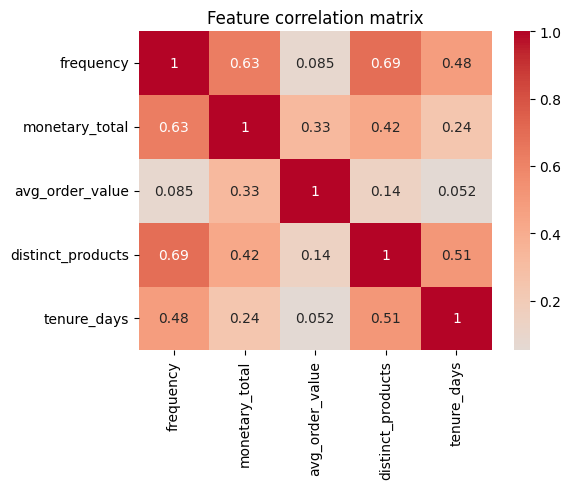

In [6]:
feat_corr = df[["frequency","monetary_total","avg_order_value","distinct_products","tenure_days"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(feat_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

**Observation:** `frequency` and `distinct_products` are highly correlated (0.69) — customers who order often also buy a wider variety. This matters for Logistic Regression (multicollinearity inflates coefficient variance) but not for tree-based models (Random Forest, XGBoost), which handle correlated features natively.

## 5. Distribution skew (do we need log-transforms?)

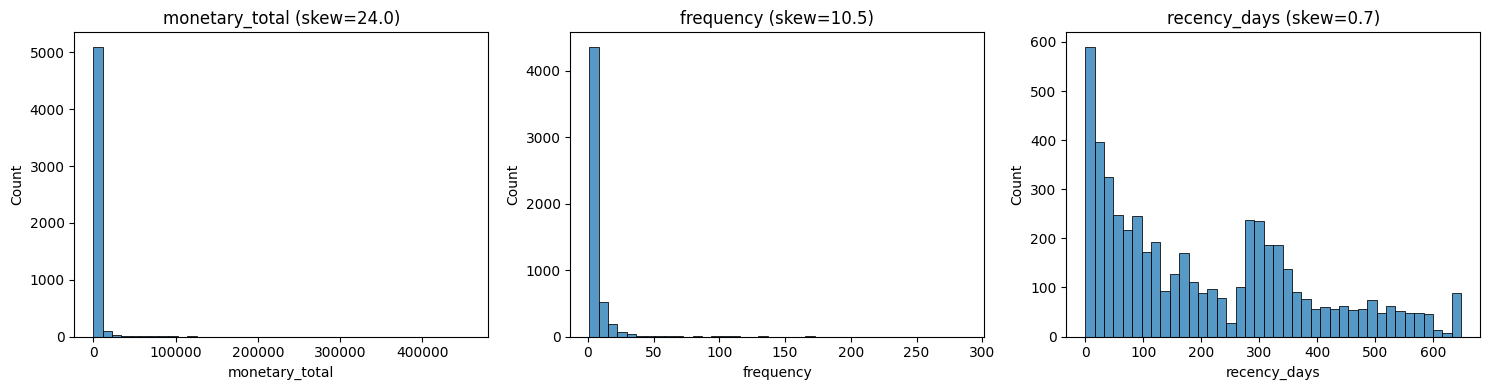

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["monetary_total","frequency","recency_days"]):
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(f"{col} (skew={df[col].skew():.1f})")
plt.tight_layout()
plt.show()

**Observation:** `monetary_total` (skew 24.0) and `frequency` (skew 10.5) are heavily right-skewed — a small number of very high-spending, very frequent customers. We'll apply a log-transform to these two before feeding them to Logistic Regression (tree-based models are unaffected by monotonic transforms, so this only matters for the linear baseline).

## 6. Country effect

In [8]:
top_countries = df["country"].value_counts().head(5).index
df[df["country"].isin(top_countries)].groupby("country")["churned"].agg(["mean","count"])

,mean,count
country,,
Belgium,0.407407,27
France,0.428571,77
Germany,0.402174,92
Spain,0.500000,30
United Kingdom,0.567410,4799


**Observation:** 92% of customers are UK-based, with a churn rate of 56.7%; the small non-UK groups (Germany, France, Belgium, Spain — each under 100 customers) sit around 40-50% but with too little data to trust the difference. We'll keep Country but group every non-UK value into a single 'Other' bucket to avoid one-hot-encoding noise from tiny categories.

## Summary — decisions carried into modeling

1. **Log-transform** `monetary_total` and `frequency` for the Logistic Regression baseline only.
2. Keep `frequency` and `distinct_products` despite their correlation — tree models handle it, and we'll check Logistic Regression coefficients for instability separately.
3. Collapse `country` into `UK` vs `Other` (too few non-UK samples to encode individually).
4. Class balance (56/44) is close enough to skip resampling (SMOTE/class-weighting) as a first pass; revisit only if recall on the minority class is poor.
5. Strongest expected predictors going in: `recency_days`, `tenure_days`, `distinct_products`, `frequency`.